# Sprint 22 — Plots de présentation
## Datasets CMAPSS & Paderborn + INT8 Python

**Expériences couvertes** : `exp_S22_01` à `exp_S22_08`, `exp_S22_INT8_01`, `exp_S22_INT8_02`

**Datasets** :
- CMAPSS (NASA Turbofan) : 4 tâches domain-incremental (FD001–FD004)
- Paderborn Bearing : 3 tâches (K001=sain, KA04=dommage artificiel, KI04=dommage réel)

**Modèles testés** : EWC, HDC, TinyOL (PC Python)

In [1]:
import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

# Paths
ROOT = Path("..")
EXP = ROOT / "experiments"
FIG_DIR = EXP / "figures" / "sprint22"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Style global
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})
np.random.seed(42)

print("Setup OK — figures dans", FIG_DIR)

Setup OK — figures dans ../experiments/figures/sprint22


## 1. Chargement des métriques CL (S22)

In [2]:
# Expériences S22 — les résultats sont dans results/metrics_cl.json ou results/metrics.json
s22_specs = [
    ("exp_S22_01", "EWC",         "CMAPSS",   "results/metrics_cl.json"),
    ("exp_S22_02", "HDC",         "CMAPSS",   "results/metrics_cl.json"),
    ("exp_S22_03", "TinyOL",      "CMAPSS",   "results/metrics.json"),
    ("exp_S22_05", "EWC",         "Paderborn","results/metrics_cl.json"),
    ("exp_S22_07", "TinyOL",      "Paderborn","results/metrics.json"),
    ("exp_S22_08", "HDC",         "Paderborn","results/metrics_cl.json"),
]

records = []
for exp_id, model, dataset, rel_path in s22_specs:
    path = EXP / exp_id / rel_path
    if path.exists():
        with open(path) as f:
            d = json.load(f)
        records.append({
            "exp_id":       exp_id,
            "model":        model,
            "dataset":      dataset,
            "acc_final":    d.get("acc_final", float("nan")),
            "avg_forgetting": d.get("avg_forgetting", float("nan")),
            "ram_peak_bytes": d.get("ram_peak_bytes", float("nan")),
            "n_params":     d.get("n_params", float("nan")),
            "acc_matrix":   d.get("acc_matrix", None),
        })
    else:
        print(f"⚠️  Fichier manquant : {path}")

df = pd.DataFrame(records)
print(df[["exp_id","model","dataset","acc_final","avg_forgetting"]].to_string(index=False))

    exp_id  model   dataset  acc_final  avg_forgetting
exp_S22_01    EWC    CMAPSS   0.914438        0.000162
exp_S22_02    HDC    CMAPSS   0.862100        0.042623
exp_S22_03 TinyOL    CMAPSS   0.894481        0.018357
exp_S22_05    EWC Paderborn   0.666667        0.500000
exp_S22_07 TinyOL Paderborn   0.666667        0.500000
exp_S22_08    HDC Paderborn   0.333333        0.000000


## 2. Accuracy finale par modèle × dataset

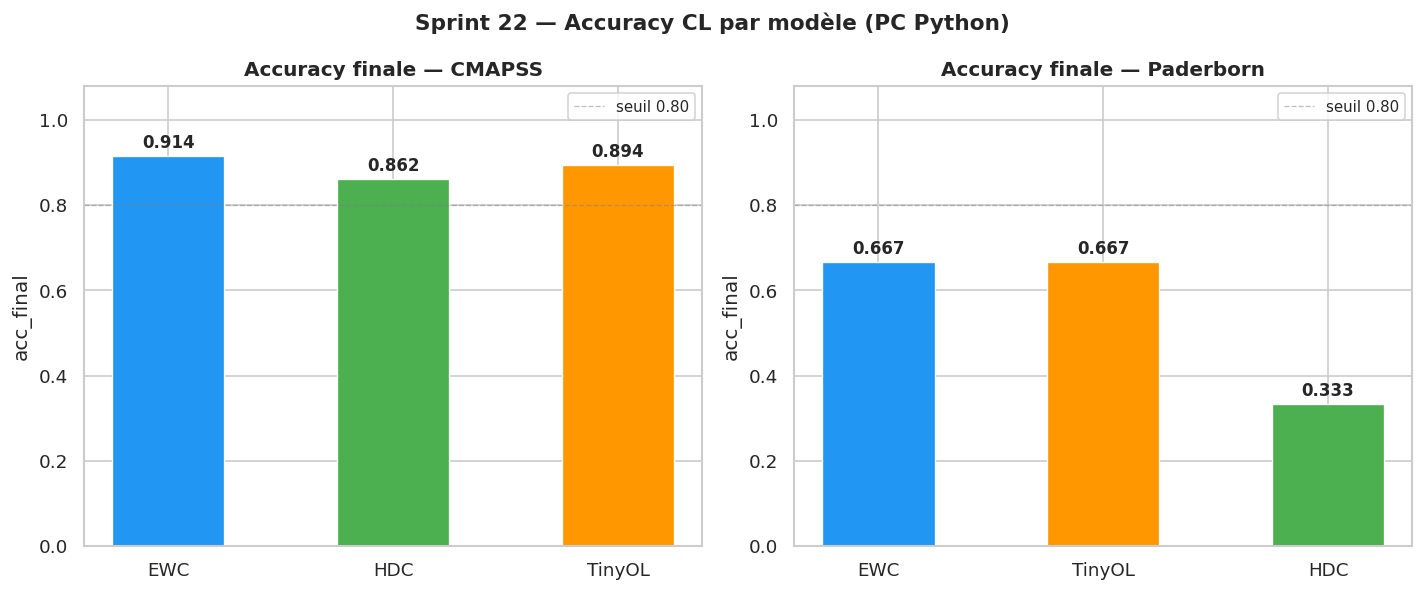

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False)

PALETTE = {"EWC": "#2196F3", "HDC": "#4CAF50", "TinyOL": "#FF9800"}

for ax, dataset in zip(axes, ["CMAPSS", "Paderborn"]):
    sub = df[df["dataset"] == dataset].copy()
    colors = [PALETTE.get(m, "gray") for m in sub["model"]]
    bars = ax.bar(sub["model"], sub["acc_final"], color=colors, width=0.5,
                  edgecolor="white", linewidth=0.8)
    for bar, val in zip(bars, sub["acc_final"]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{val:.3f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
    ax.set_title(f"Accuracy finale — {dataset}", fontweight="bold")
    ax.set_ylabel("acc_final")
    ax.set_ylim(0, 1.08)
    ax.axhline(0.8, color="gray", linestyle="--", linewidth=0.8, alpha=0.5, label="seuil 0.80")
    ax.legend(fontsize=9)

fig.suptitle("Sprint 22 — Accuracy CL par modèle (PC Python)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "acc_by_model_dataset.png", bbox_inches="tight")
plt.show()

## 3. Forgetting par modèle × dataset

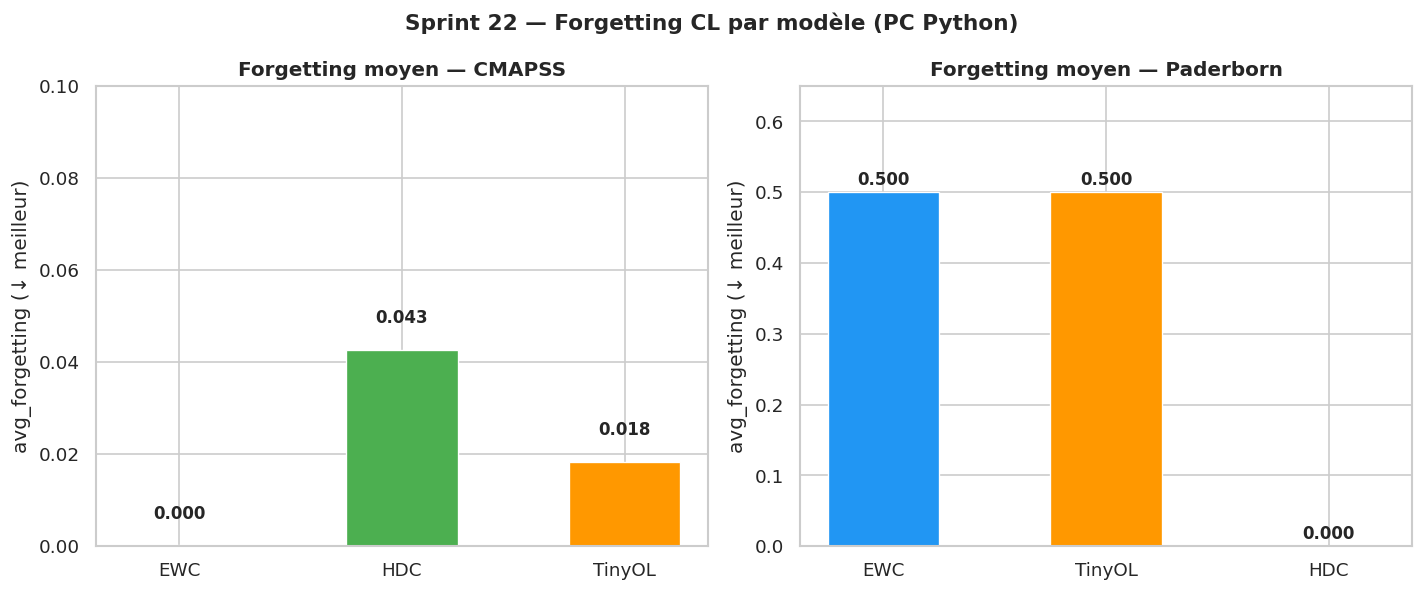

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False)

for ax, dataset in zip(axes, ["CMAPSS", "Paderborn"]):
    sub = df[df["dataset"] == dataset].copy()
    colors = [PALETTE.get(m, "gray") for m in sub["model"]]
    bars = ax.bar(sub["model"], sub["avg_forgetting"], color=colors, width=0.5,
                  edgecolor="white", linewidth=0.8)
    for bar, val in zip(bars, sub["avg_forgetting"]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f"{val:.3f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
    ax.set_title(f"Forgetting moyen — {dataset}", fontweight="bold")
    ax.set_ylabel("avg_forgetting (↓ meilleur)")
    ax.set_ylim(0, max(sub["avg_forgetting"].max() * 1.3, 0.1))

fig.suptitle("Sprint 22 — Forgetting CL par modèle (PC Python)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "forgetting_by_model_dataset.png", bbox_inches="tight")
plt.show()

## 4. Heatmaps acc_matrix — Trajectoire CL par tâche (EWC CMAPSS)

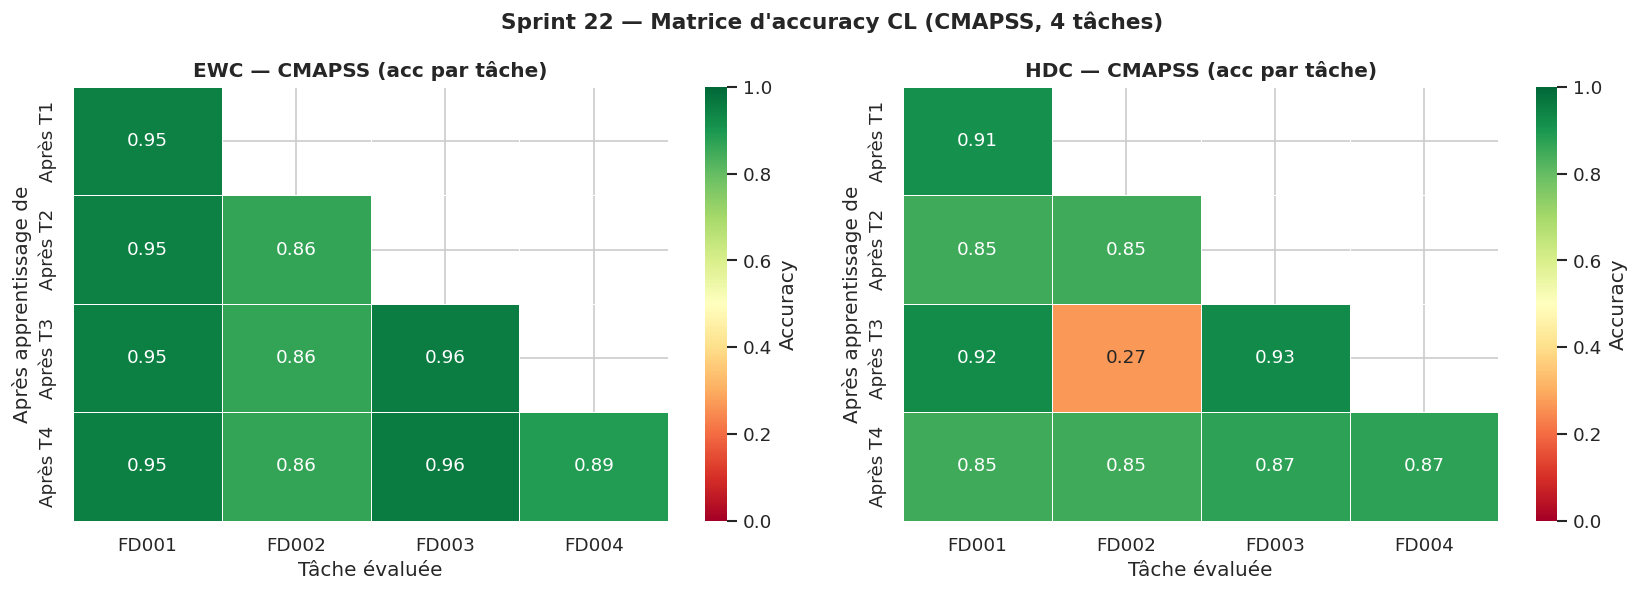

In [5]:
def plot_acc_matrix(acc_matrix, title, ax, task_names=None):
    """Heatmap de la matrice d'accuracy CL (ligne=après tâche i, colonne=tâche j)."""
    n = len(acc_matrix)
    mat = np.full((n, n), np.nan)
    for i, row in enumerate(acc_matrix):
        for j, val in enumerate(row):
            if val is not None and not (isinstance(val, float) and np.isnan(val)):
                mat[i, j] = val
    labels = task_names or [f"T{j+1}" for j in range(n)]
    row_labels = [f"Après T{i+1}" for i in range(n)]
    mask = np.isnan(mat)
    sns.heatmap(mat, ax=ax, vmin=0, vmax=1, annot=True, fmt=".2f", mask=mask,
                cmap="RdYlGn", linewidths=0.5, cbar_kws={"label": "Accuracy"},
                xticklabels=labels, yticklabels=row_labels)
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Tâche évaluée")
    ax.set_ylabel("Après apprentissage de")

# EWC CMAPSS
ewc_cmapss = df[(df["model"]=="EWC") & (df["dataset"]=="CMAPSS")].iloc[0]
hdc_cmapss = df[(df["model"]=="HDC") & (df["dataset"]=="CMAPSS")].iloc[0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
task_names = ["FD001", "FD002", "FD003", "FD004"]
if ewc_cmapss["acc_matrix"] is not None:
    plot_acc_matrix(ewc_cmapss["acc_matrix"], "EWC — CMAPSS (acc par tâche)", axes[0], task_names)
if hdc_cmapss["acc_matrix"] is not None:
    plot_acc_matrix(hdc_cmapss["acc_matrix"], "HDC — CMAPSS (acc par tâche)", axes[1], task_names)

fig.suptitle("Sprint 22 — Matrice d'accuracy CL (CMAPSS, 4 tâches)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "acc_matrix_cmapss.png", bbox_inches="tight")
plt.show()

## 5. Heatmap acc_matrix — EWC Paderborn (3 tâches)

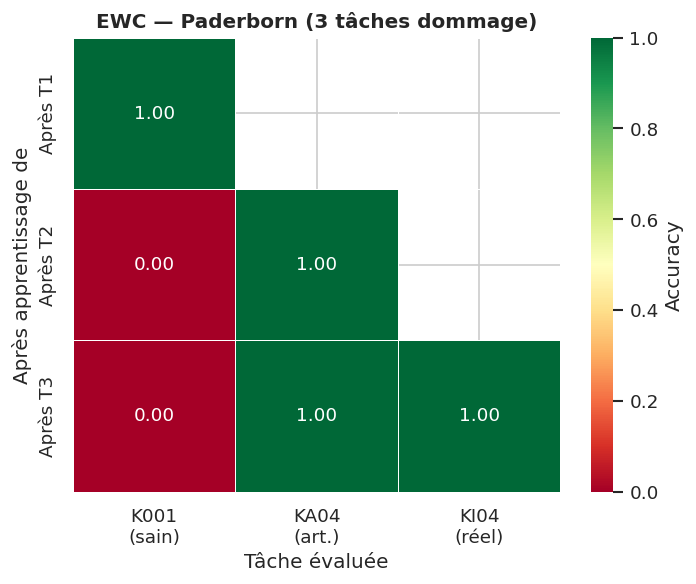

→ Observation : après T1 (K001), T0 perd toute accuracy = catastrophic forgetting sur Paderborn.


In [6]:
ewc_pad = df[(df["model"]=="EWC") & (df["dataset"]=="Paderborn")].iloc[0]

fig, ax = plt.subplots(figsize=(6, 5))
task_names_pad = ["K001\n(sain)", "KA04\n(art.)", "KI04\n(réel)"]
if ewc_pad["acc_matrix"] is not None:
    plot_acc_matrix(ewc_pad["acc_matrix"], "EWC — Paderborn (3 tâches dommage)", ax, task_names_pad)

plt.tight_layout()
plt.savefig(FIG_DIR / "acc_matrix_paderborn_ewc.png", bbox_inches="tight")
plt.show()
print("→ Observation : après T1 (K001), T0 perd toute accuracy = catastrophic forgetting sur Paderborn.")

## 6. INT8 vs FP32 — Compression RAM et préservation accuracy

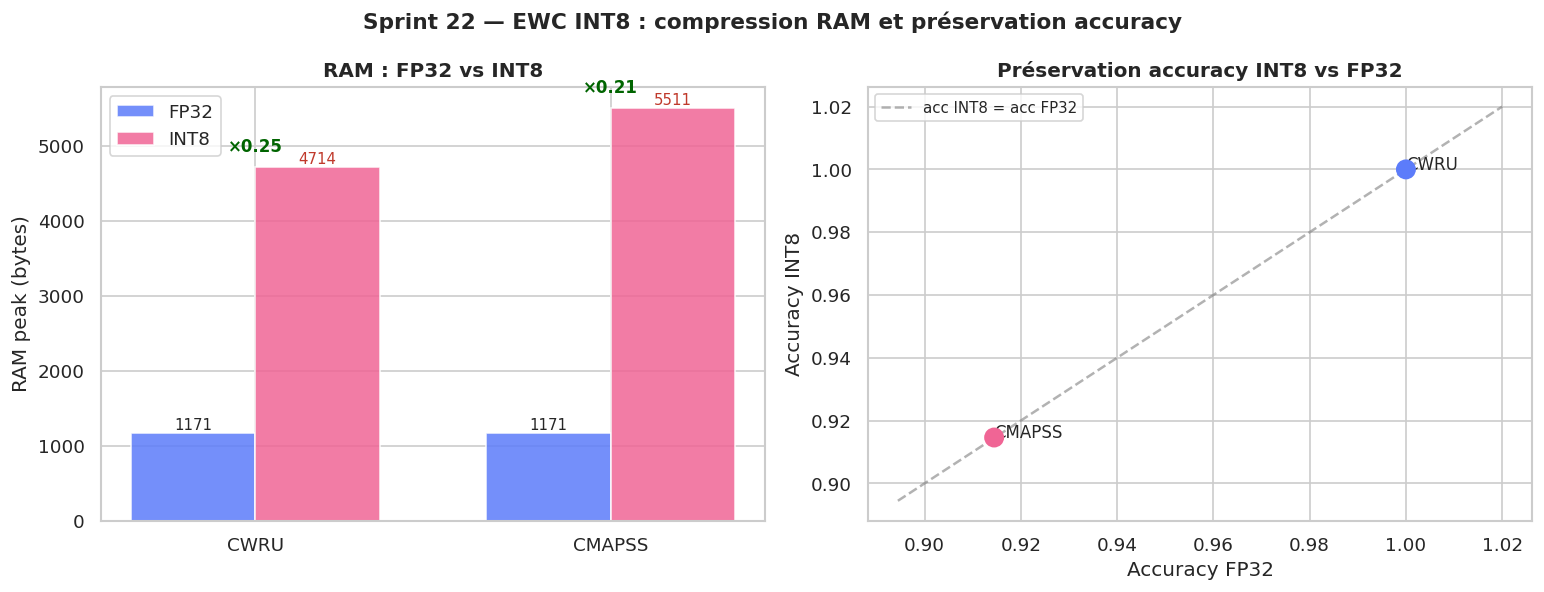

In [7]:
# Données INT8 depuis exp_S22_INT8_01 et _02
int8_data = []
for exp_id, dataset_name in [("exp_S22_INT8_01", "CWRU"), ("exp_S22_INT8_02", "CMAPSS")]:
    path = EXP / exp_id / "results" / "results.json"
    if path.exists():
        with open(path) as f:
            d = json.load(f)
        int8_data.append({
            "dataset": dataset_name,
            "acc_fp32": d["fp32"]["acc_final"],
            "acc_int8": d["int8"]["acc_final"],
            "ram_fp32": d["fp32"]["ram_peak_bytes"],
            "ram_int8": d["int8"]["ram_peak_bytes"],
            "auroc_fp32": d["fp32"]["auroc_final"],
            "auroc_int8": d["int8"]["auroc_final"],
        })

df_int8 = pd.DataFrame(int8_data)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Plot 1 : RAM comparison
ax = axes[0]
x = np.arange(len(df_int8))
w = 0.35
b1 = ax.bar(x - w/2, df_int8["ram_fp32"], w, label="FP32", color="#5C7CFA", alpha=0.85)
b2 = ax.bar(x + w/2, df_int8["ram_int8"], w, label="INT8", color="#F06595", alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(df_int8["dataset"])
ax.set_ylabel("RAM peak (bytes)")
ax.set_title("RAM : FP32 vs INT8", fontweight="bold")
ax.legend()
for bar in b1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+40,
            f"{int(bar.get_height())}", ha="center", fontsize=9)
for bar in b2:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+40,
            f"{int(bar.get_height())}", ha="center", fontsize=9, color="#c0392b")
# Ratio annotations
for i, row in df_int8.iterrows():
    ratio = row["ram_fp32"] / row["ram_int8"]
    ax.text(i, max(row["ram_fp32"], row["ram_int8"]) + 200, f"×{ratio:.2f}",
            ha="center", fontsize=10, fontweight="bold", color="darkgreen")

# Plot 2 : Accuracy preservation
ax = axes[1]
ax.scatter(df_int8["acc_fp32"], df_int8["acc_int8"], s=120, zorder=5,
           c=["#5C7CFA", "#F06595"])
for _, row in df_int8.iterrows():
    ax.annotate(row["dataset"],
                (row["acc_fp32"], row["acc_int8"]),
                xytext=(0.003, -0.015), textcoords="offset points",
                fontsize=10)
lo = min(df_int8[["acc_fp32","acc_int8"]].min()) - 0.02
hi = max(df_int8[["acc_fp32","acc_int8"]].max()) + 0.02
ax.plot([lo, hi], [lo, hi], "--", color="gray", alpha=0.6, label="acc INT8 = acc FP32")
ax.set_xlabel("Accuracy FP32")
ax.set_ylabel("Accuracy INT8")
ax.set_title("Préservation accuracy INT8 vs FP32", fontweight="bold")
ax.legend(fontsize=9)

fig.suptitle("Sprint 22 — EWC INT8 : compression RAM et préservation accuracy",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "int8_vs_fp32.png", bbox_inches="tight")
plt.show()

## 7. Vue synthèse — acc vs forgetting (Sprint 22)

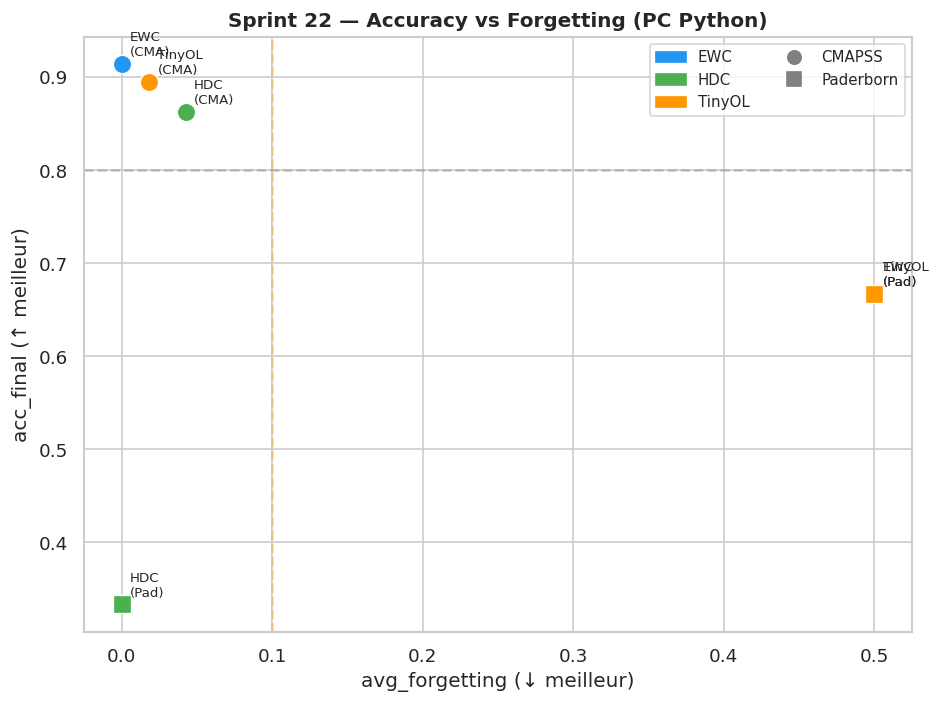

In [8]:
fig, ax = plt.subplots(figsize=(8, 6))

MARKERS = {"CMAPSS": "o", "Paderborn": "s"}
for _, row in df.iterrows():
    ax.scatter(row["avg_forgetting"], row["acc_final"],
               c=PALETTE.get(row["model"], "gray"),
               marker=MARKERS.get(row["dataset"], "^"),
               s=120, zorder=5, edgecolors="white", linewidths=0.8)
    ax.annotate(f"{row['model']}\n({row['dataset'][:3]})",
                (row["avg_forgetting"], row["acc_final"]),
                xytext=(5, 5), textcoords="offset points", fontsize=8)

# Légendes manuelles
patches = [mpatches.Patch(color=c, label=m) for m, c in PALETTE.items()]
from matplotlib.lines import Line2D
lines = [Line2D([0],[0], marker=m, color="gray", linestyle="None", markersize=8, label=d)
         for d, m in MARKERS.items()]
ax.legend(handles=patches + lines, fontsize=9, ncol=2)

ax.set_xlabel("avg_forgetting (↓ meilleur)")
ax.set_ylabel("acc_final (↑ meilleur)")
ax.set_title("Sprint 22 — Accuracy vs Forgetting (PC Python)", fontweight="bold")
ax.axhline(0.8, color="gray", linestyle="--", alpha=0.4)
ax.axvline(0.1, color="orange", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig(FIG_DIR / "acc_vs_forgetting.png", bbox_inches="tight")
plt.show()

## Récapitulatif figures générées

In [9]:
figs = sorted(FIG_DIR.glob("*.png"))
print(f"\n{len(figs)} figures sauvegardées dans {FIG_DIR}:")
for f in figs:
    print(f"  {f.name}")


6 figures sauvegardées dans ../experiments/figures/sprint22:
  acc_by_model_dataset.png
  acc_matrix_cmapss.png
  acc_matrix_paderborn_ewc.png
  acc_vs_forgetting.png
  forgetting_by_model_dataset.png
  int8_vs_fp32.png
